## Getting Started

Welcome! This notebook aims to help you gain a foundational understanding of resplotlib. It covers the basics of how to use the `resplotclass`, which is the core class of resplotlib, and how to apply `guidelines` to your plots. By the end of this notebook, you should be able to create your own resilient plots using resplotlib. Let's get started!

### Resplotclass

The `resplotclass` is the core class of resplotlib. It contains methods that wrap the plotting functionality of various other libraries, including [xarray](http://xarray.pydata.org/en/stable/), [xugrid](https://deltares.github.io/xugrid/), [geopandas](https://geopandas.org/), [contextily](https://contextily.readthedocs.io/en/latest/), [matplotlib](https://matplotlib.org/stable/index.html) and [ipyleaflet](https://ipyleaflet.readthedocs.io/en/latest/).

To import the `resplotclass` (abbreviated as `rpc`), use the following code:

In [1]:
from resplotlib import rpc

### Guidelines

The `resplotclass` contains a `guidelines` attribute, which is a dictionary of dictionaries that contain keyword arguments (kwargs) that can be applied to the plotting methods of the resplotclass. These guidelines are designed to make it easier for users to create plots that are consistent with certain styles or extents. They can be applied in the plotting methods of the resplotclass by using the `style` and `extent` keywords. The resplotclass comes with default guidelines to make your plots more consistent and visually appealing. Depending on your project, you may want to apply certain styles or extents. This can be done by creating your own project guidelines and setting them to the `guidelines` attribute of the `resplotclass`. To find out more about guidelines, and how to specify, set and apply them, see the [Guidelines notebook](./02_guidelines.ipynb).

To show the `guidelines` that are currently set in the `resplotclass`, use the following method:

In [2]:
rpc.show_guidelines()

### Supported Data Types

The `resplotclass` supports a variety of data types, including `xarray.DataArray`, `xarray.Dataset`, `xugri.UgridDataArray`, `xugrid.UgridDataset`, and `geopandas.GeoDataFrame`. These types contain both the data, metadata and coordinate reference system (CRS). Here, a CRS is added to the `xugrid.UgridDataArray` as it is generally not included in the netCDF file.

To read the data required for this notebook, use the following code:

In [3]:
# Packages
from pathlib import Path

import geopandas as gpd
import rioxarray as rxr
import xugrid as xu

# Directories
dir_path_repo = next(p for p in Path.cwd().resolve().parents if p.name == "resplotlib")
dir_path_data = dir_path_repo / "data"

# Read data
da_bathymetry = rxr.open_rasterio(dir_path_data / "bathymetry.tif").squeeze()
da_image = rxr.open_rasterio(dir_path_data / "image.tif").squeeze()
uds_model = xu.open_dataset(dir_path_data / "model.nc")
gdf_points = gpd.read_file(dir_path_data / "points.geojson")
gdf_lines = gpd.read_file(dir_path_data / "shorelines.geojson")
gdf_polygons = gpd.read_file(dir_path_data / "polygons.geojson")

# Add a coordinate reference system (CRS)
uds_model.ugrid.set_crs("EPSG:32631", allow_override=True)

# Get bounds and limits
bounds = da_bathymetry.rio.bounds()
xlim = (bounds[0], bounds[2])
ylim = (bounds[1], bounds[3])

### Static plotting

The `resplotclass` provides the following static plot methods: `imshow`, `pcolormesh`, `contourf`, `quiver`, `streamplot`, `geometries`, `basemap`. Moreover, the following methods are available to create a figure and axes, show the plot and save the plot: `figure`, `axes`, `show` and `save`. To find out more about static plotting, see the [Static plotting notebook](./03_static_plotting.ipynb).

Here a figure and axes are created using the `figure` and `axes` methods of the `resplotclass`. The `imshow` method is used to plot an `xarray.DataArray` and `xugrid.UgridDataArray`, while the `geometries` method is used to plot a `geopandas.GeoDataFrame`. Basemaps are added to the axes using the `basemap` method. Finally, the plot is shown using the `show` method.

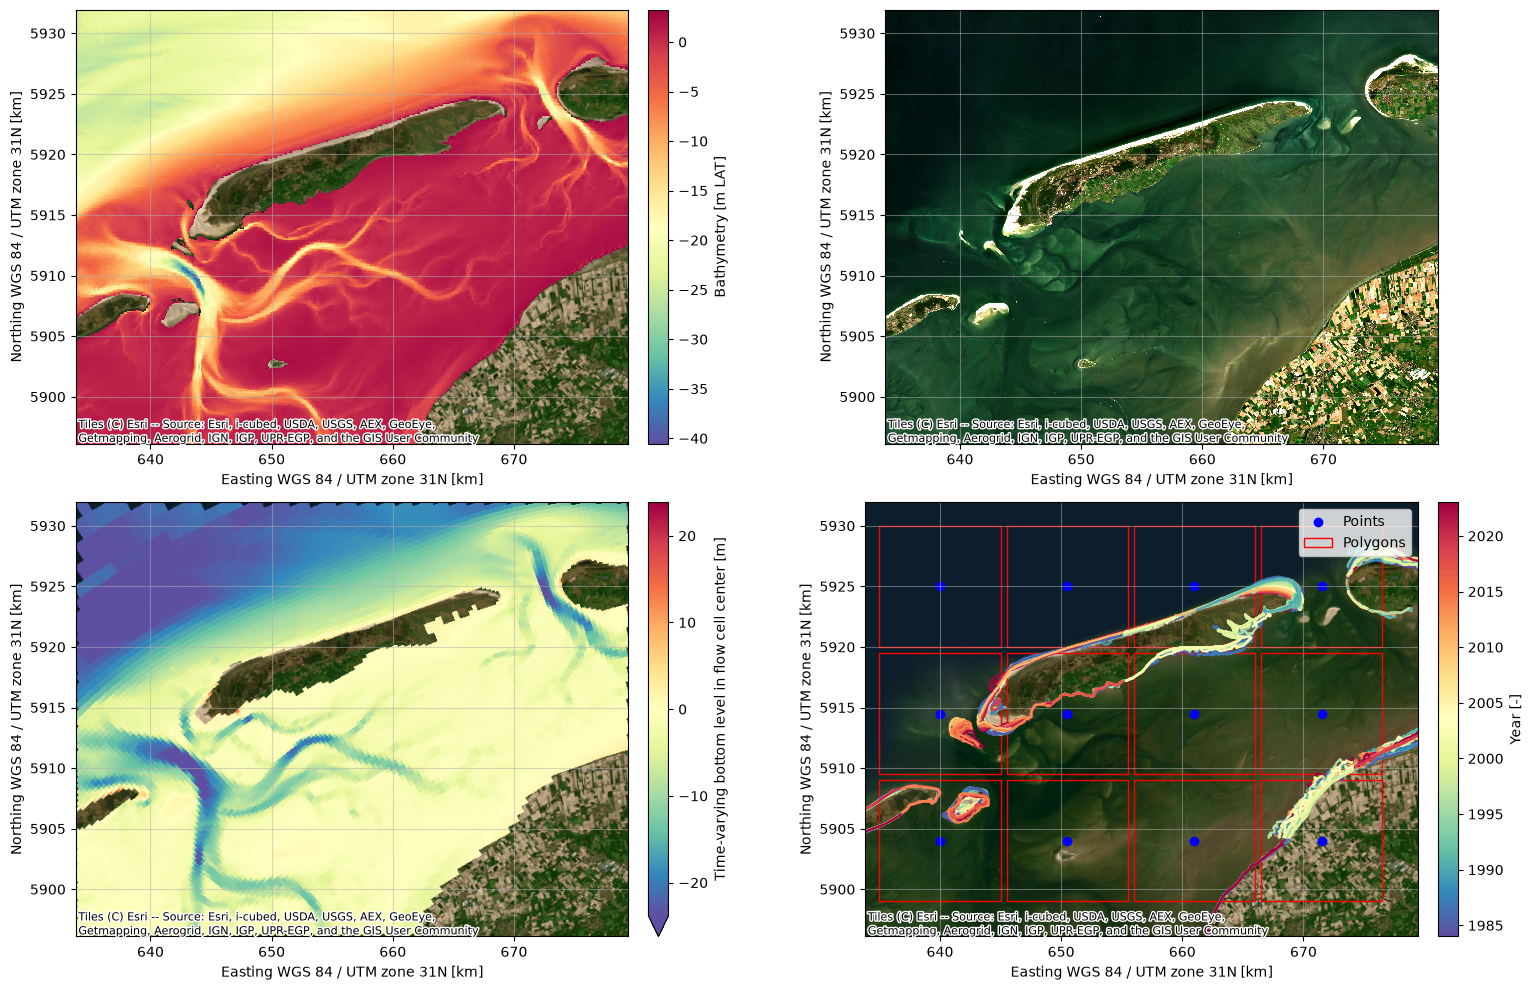

In [4]:
# Initialise figure and axes
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

# Plot bathymetry
rpc.imshow(da=da_bathymetry, ax=axs[0], style="bathymetry")

# Plot image
rpc.imshow(da=da_image, ax=axs[1], style="image")

# Plot elevation
rpc.imshow(uda=uds_model["mesh2d_mor_bl"], ax=axs[2], robust=True)

# Plot geometries
rpc.geometries(gdf=gdf_points, ax=axs[3], color="blue", label="Points")
rpc.geometries(gdf=gdf_lines, ax=axs[3], column="year", cmap="Spectral_r", legend=True, legend_kwds={"label": "Year [-]"})
rpc.geometries(gdf=gdf_polygons, ax=axs[3], facecolor="none", edgecolor="red", label="Polygons")
axs[3].legend(loc="upper right")

# Plot basemaps
for ax in axs:
    rpc.basemap("EPSG:32631", ax=ax, style="satellite", xlim=xlim, ylim=ylim)

# Show image
rpc.show(fig)

### Interactive plotting

The `resplotclass` provides the following interactive plot methods: `explore_data`, `explore_geometries`, `explore_basemap`. Morever, the following methods are available to create a map, show the map and save the map: `Map`, `show` and `save`. The `Map` method creates an interactive map using `ipyleaflet`, which allows users to interact with the map and the plotted data. The `Map` method also contains a draw control layer, which allows users to interactively draw and edit geometries on the map. The map contain various methods to retrieve information about the map, such as the current view bounds, zoom level and drawn geometries. To find out more about interactive plotting, see the [Interactive plotting notebook](./04_interactive_plotting.ipynb).

Here, the `Map` method is used to create a map. A `geopandas.GeoDataFrame` is supplied to the `Map` and set to the map's draw control layer. This is a layer in which the user can interactively draw and edit geometries. The `explore_data` method is used to plot an `xarray.DataArray` and `xugrid.UgridDataArray`, while the `explore_geometries` method is used to plot a `geopandas.GeoDataFrame`. Basemaps are added to the axes using the `explore_basemap` method. Finally, the map is shown using the `show` method.

Next, current view bounds, zoom level and drawn geometries are retrieved from the map using the `get_view_bounds()`, `get_view_zoom_levels()` and `get_drawn_geometries()` methods of the `Map`.

In [5]:
# Initialise map
m = rpc.Map(gdf=gdf_points)

# Plot bathymetry
m = rpc.explore_data(da=da_bathymetry, m=m, style="bathymetry", name="Bathymetry", add_colorbar=True, cbar_kwargs={"label": "Depth [m]"})

# Plot image
m = rpc.explore_data(da=da_image, m=m, style="image", name="Image")

# Plot elevation
m = rpc.explore_data(da=uds_model["mesh2d_ucmag"], m=m, name="Velocity magnitude")

# Plot geometries
m = rpc.explore_geometries(gdf=gdf_lines, m=m, column="year", cmap="Spectral_r", name="Shorelines", legend=True, label="Year [-]")
m = rpc.explore_geometries(gdf=gdf_polygons, m=m, name="Polygons")

# Plot basemaps
m = rpc.explore_basemap(m=m, style="satellite")

# Show map
rpc.show(m)

c:\Users\white_rn\Documents\GitHub\resplotlib\.venv\Lib\site-packages\odc\geo\_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")


Map(center=[np.float64(53.35644024865398), np.float64(5.340823071326232)], controls=(ZoomControl(options=['pos…

In [6]:
# Get view bounds
print("View bounds:", m.get_view_bounds())

# Get view zoom
print("View zoom:", m.get_view_zoom())

# Get drawn geometries
gdf_drawn = m.get_drawn_geometries()

# Show drawn geometries
gdf_drawn.head()

View bounds: (nan, nan, nan, nan)
View zoom: 10.0


,letter,geometry
0,r,POINT (5.1085 53.45538)
1,e,POINT (5.26651 53.45249)
2,s,POINT (5.42449 53.44939)
3,,POINT (5.58244 53.44607)
4,p,POINT (5.10384 53.36106)
